# Definições gerais:

- Os grafos devem ser gerados aleatóriamente.
- Devem ser gerados três grafos não-orientados, simples e conexos.
- Os grafos devem ser diferentes.
- No mínimo 5 e no máximo 10 vértices.

In [1]:
# Compilar o projeto
!make

gcc -Wall -Wextra -std=c17  -c main.c -o main.o
gcc -Wall -Wextra -std=c17  -c utils.c -o utils.o
gcc -Wall -Wextra -std=c17  -c Base/adjacentListGraph.c -o Base/adjacentListGraph.o
gcc -Wall -Wextra -std=c17  -c Algoritmos_de_Busca/dfs.c -o Algoritmos_de_Busca/dfs.o
gcc -Wall -Wextra -std=c17  -c Algoritmos_Extras/fleury.c -o Algoritmos_Extras/fleury.o
gcc -Wall -Wextra -std=c17  -c Algoritmos_Extras/tarjan_for_articulation.c -o Algoritmos_Extras/tarjan_for_articulation.o
gcc -Wall -Wextra -std=c17  -c Algoritmos_Extras/planar.c -o Algoritmos_Extras/planar.o
gcc -Wall -Wextra -std=c17  -o graph main.o utils.o Base/adjacentListGraph.o Base/adjacentMatrizGraph.o Algoritmos_de_Busca/dfs.o Algoritmos_de_Busca/bfs.o Algoritmos_Extras/fleury.o Algoritmos_Extras/tarjan_for_articulation.o Algoritmos_Extras/planar.o


In [2]:
# Dependências
!pip install matplotlib
!pip install networkx

  Using cached contourpy-1.3.3-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 4.4 MB/s  0:00:02 eta 0:00:01
Using cached contourpy-1.3.3-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (363 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (4.9 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (1.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 3.8 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━

In [3]:
# Imports
import json
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

## Questão a:

**Tarefa:** Verificar planaridade em um grafo.

---

**Como foi feito:** Utiliza o Teorema de Kuratowski e as checagens de Euler.

1. Verifica as condições necessárias, mas não suficientes: 
    - $E \le 3V - 6$, utilizei essa pois ela serve como limite superior, se eu usasse a do bipartido eu poderia classificar erroneamente alguns como planares.
    - Número de vértices de grau par.
    - Número de vértices de grau ímpar.
2. Simplifica o grafo. Identifica os vértices de grau 2, retira eles e conecta os vértices que ele estava interligando diretamente.
3. Busca pelo K5 e pelo K3,3 no grafo.

## Questão b:

**Tarefa:** Verificar a existência de pontos de articulação.

---

**Como foi feito:** Atráves do algoritmo de Tarjan.

1. Usa o DFS para varrer o grafo, registrando o start_time e o low_time, que é o menor tempo de descoberta possível, utilizando no máximo uma aresta de retorno.
2. Na volta da busca, o código identifica se um vértice é um ponto de articulação usando duas regras:
    - Se NÃO for a raiz: Ele será uma articulação se tiver um "filho" na busca que não consegue voltar para nenhum vértice anterior a ele (lowTime do filho >= startTime do pai). Isso significa que o filho depende do pai para continuar conectado ao resto do grafo.
    - Se FOR a raiz: A regra do tempo não funciona para a raiz. Então, o código apenas conta seus filhos diretos. Se a raiz tiver 2 ou mais filhos independentes, ela é uma articulação.

## Questão c:

**Tarefa:** Verificar se um grafo possui ciclo euleriano.

---

**Como foi feito:** Atráves do algoritmo de Fleury.

1. Caminhada com a "Regra da Ponte": Partindo de um vértice inicial, o algoritmo entra em um laço para escolher a próxima aresta a ser atravessada. Para decidir se a escolha é válida, ele usa a função isValidNextEdge:
    - Se for a única aresta do vértice: O algoritmo é obrigado a usá-la.
    - Se houver mais opções: O código faz um teste temporário (usando DFS) para ver se a remoção dessa aresta desconectaria o grafo (ou seja, se ela é uma "ponte"). O algoritmo evita queimar pontes a menos que não haja outra alternativa, garantindo que o caminho não fique preso antes da hora.
2. Remoção e Atualização: Assim que encontra uma aresta que respeita a regra da ponte, o algoritmo imprime o passo, remove essa aresta definitivamente da cópia do grafo e pula para o próximo vértice, repetindo o processo até que todas as arestas sejam consumidas.


Um detalhe matemático importante sobre a Questão C: O seu fleury_list apenas tenta caminhar pelas arestas. Para responder corretamente "se existe ou não um ciclo euleriano", você não deve rodar o Fleury às cegas. Pelo Teorema de Euler, você deve primeiro contar o grau dos vértices:

- Se todos os vértices tiverem grau par: Existe um Ciclo Euleriano. Você inicia o Fleury de qualquer vértice.
- Se exatamente 2 vértices tiverem grau ímpar: Existe apenas um Caminho Euleriano. Você deve iniciar o Fleury de um desses vértices ímpares.
- Qualquer outro caso: Não existe caminho nem ciclo. O algoritmo nem precisa ser rodado.

## Execução

### Funções auxiliares

In [4]:
import subprocess

def run(number_of_vertex, is_dense, seed):
    try:
        resultado = subprocess.run(
            [
                "./graph",
                f"{number_of_vertex}",
                f"{is_dense}",
                f"{seed}"
            ], 
            check=True, 
            capture_output=True, text=True
        )
        print("Executado com sucesso!")
        # print(resultado.stdout)
    except subprocess.CalledProcessError as e:
        print(f"Erro ao executar: {e}")

In [5]:
def plot():
    # 1. Carregar os dados que o C gerou
    with open("resultados_q5.json", "r", encoding="utf-8") as f:
        grafos = json.load(f)

    # 2. Iterar e exibir cada um dos 3 grafos
    for idx, data in enumerate(grafos):
        print(f"\n{'='*60}\nGRAFO {idx + 1} ({data['num_vertices']} vértices)\n{'='*60}")
        
        # --- DESENHO DO GRAFO ---
        matriz = np.array(data["matrix"])
        G = nx.from_numpy_array(matriz)
        
        plt.figure(figsize=(6, 4))
        pos = nx.spring_layout(G, seed=42) # Layout padronizado
        nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=600, font_weight='bold', edge_color='gray')
        plt.title(f"Grafo Aleatório {idx + 1}")
        plt.show()
        
        # --- QUESTÃO A: Planaridade ---
        print("A) Planaridade:")
        if data["planar"]["is_planar"]:
            print("   - O grafo É PLANAR (Passou nos testes de Euler e Kuratowski).")
        else:
            print(f"   - O grafo NÃO É PLANAR. Motivo: {data['planar']['reason']}")
            
        # --- QUESTÃO B: Pontos de Articulação ---
        print("\nB) Pontos de Articulação:")
        if data["articulation"]["has_points"]:
            print(f"   - O grafo possui pontos de articulação: {data['articulation']['points']}")
        else:
            print("   - O grafo NÃO possui pontos de articulação.")
            
        # --- QUESTÃO C: Caminho/Ciclo Euleriano ---
        print("\nC) Ciclos e Caminhos Eulerianos:")
        if data["euler"]["type"] == 2:
            print(f"   - O grafo possui um CICLO EULERIANO.")
            print(f"   - Percurso de Fleury: {' -> '.join(map(str, data['euler']['path']))}")
        elif data["euler"]["type"] == 1:
            print(f"   - O grafo possui apenas um CAMINHO EULERIANO.")
            print(f"   - Percurso de Fleury: {' -> '.join(map(str, data['euler']['path']))}")
        else:
            print("   - O grafo NÃO possui Caminho nem Ciclo Euleriano (falhou na contagem de graus ímpares).")

### Usando grafos densos

Executado com sucesso!

GRAFO 1 (10 vértices)


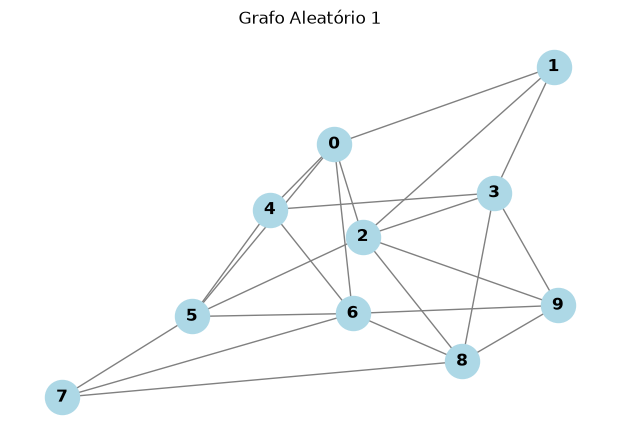

A) Planaridade:
   - O grafo É PLANAR (Passou nos testes de Euler e Kuratowski).

B) Pontos de Articulação:
   - O grafo NÃO possui pontos de articulação.

C) Ciclos e Caminhos Eulerianos:
   - O grafo NÃO possui Caminho nem Ciclo Euleriano (falhou na contagem de graus ímpares).

GRAFO 2 (10 vértices)


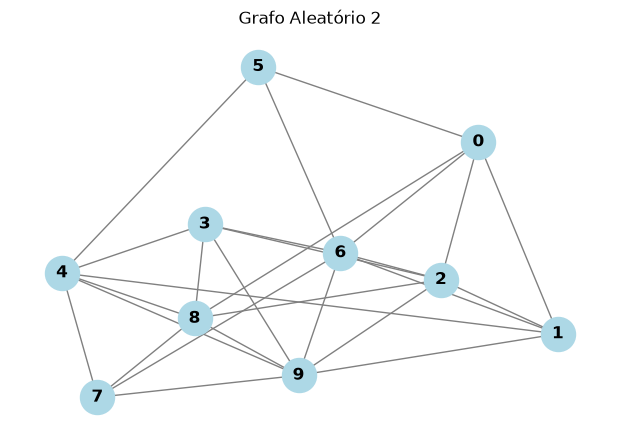

A) Planaridade:
   - O grafo NÃO É PLANAR. Motivo: Falhou no limite superior de Euler (E=27 > 3V-6)

B) Pontos de Articulação:
   - O grafo NÃO possui pontos de articulação.

C) Ciclos e Caminhos Eulerianos:
   - O grafo NÃO possui Caminho nem Ciclo Euleriano (falhou na contagem de graus ímpares).

GRAFO 3 (10 vértices)


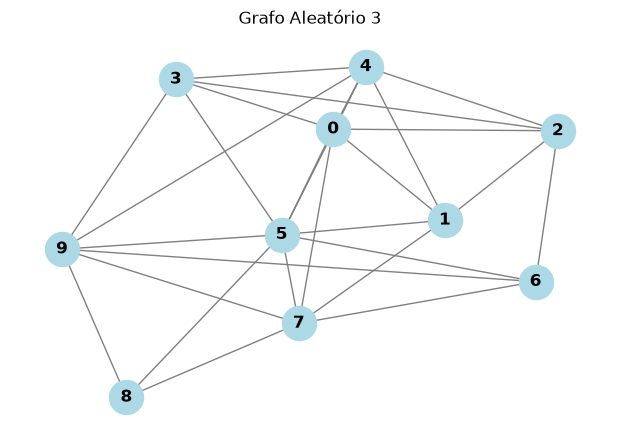

A) Planaridade:
   - O grafo NÃO É PLANAR. Motivo: Falhou no limite superior de Euler (E=27 > 3V-6)

B) Pontos de Articulação:
   - O grafo NÃO possui pontos de articulação.

C) Ciclos e Caminhos Eulerianos:
   - O grafo NÃO possui Caminho nem Ciclo Euleriano (falhou na contagem de graus ímpares).


In [6]:
run(
    number_of_vertex = 10,
    is_dense = 1,
    seed = 42
)
plot()


Executado com sucesso!

GRAFO 1 (7 vértices)


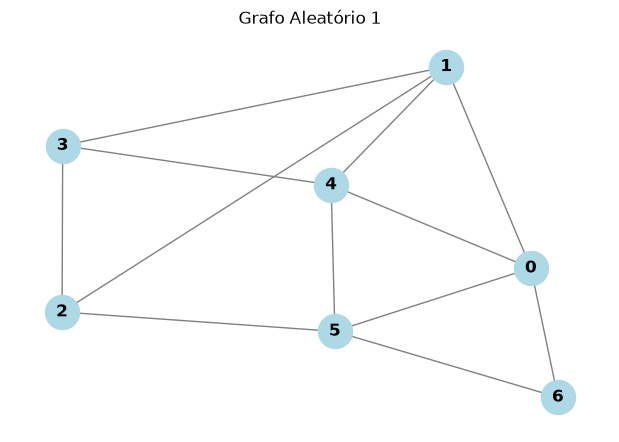

A) Planaridade:
   - O grafo É PLANAR (Passou nos testes de Euler e Kuratowski).

B) Pontos de Articulação:
   - O grafo NÃO possui pontos de articulação.

C) Ciclos e Caminhos Eulerianos:
   - O grafo possui apenas um CAMINHO EULERIANO.
   - Percurso de Fleury: 3 -> 1 -> 4 -> 0 -> 6 -> 5 -> 2 -> 3 -> 4 -> 5 -> 0 -> 1 -> 2

GRAFO 2 (7 vértices)


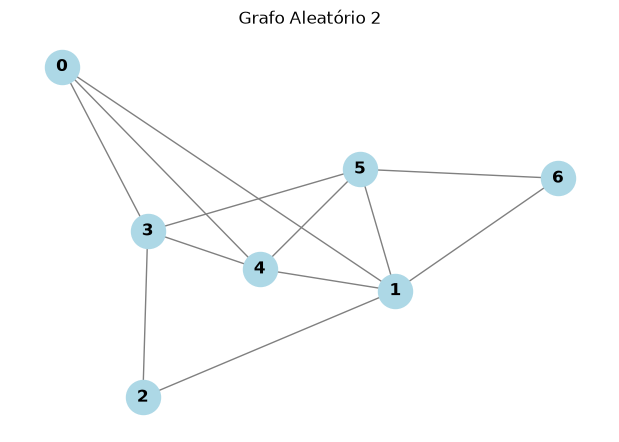

A) Planaridade:
   - O grafo É PLANAR (Passou nos testes de Euler e Kuratowski).

B) Pontos de Articulação:
   - O grafo NÃO possui pontos de articulação.

C) Ciclos e Caminhos Eulerianos:
   - O grafo possui apenas um CAMINHO EULERIANO.
   - Percurso de Fleury: 1 -> 6 -> 5 -> 3 -> 0 -> 4 -> 1 -> 5 -> 4 -> 3 -> 2 -> 1 -> 0

GRAFO 3 (7 vértices)


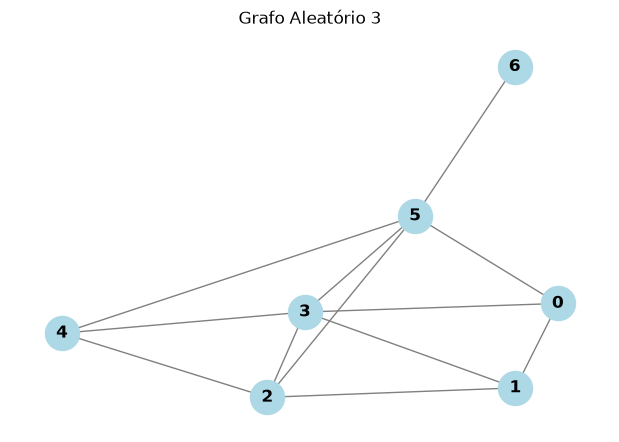

A) Planaridade:
   - O grafo É PLANAR (Passou nos testes de Euler e Kuratowski).

B) Pontos de Articulação:
   - O grafo possui pontos de articulação: [5]

C) Ciclos e Caminhos Eulerianos:
   - O grafo NÃO possui Caminho nem Ciclo Euleriano (falhou na contagem de graus ímpares).


In [7]:
run(
    number_of_vertex = 7,
    is_dense = 1,
    seed = 42
)
plot()


Executado com sucesso!

GRAFO 1 (5 vértices)


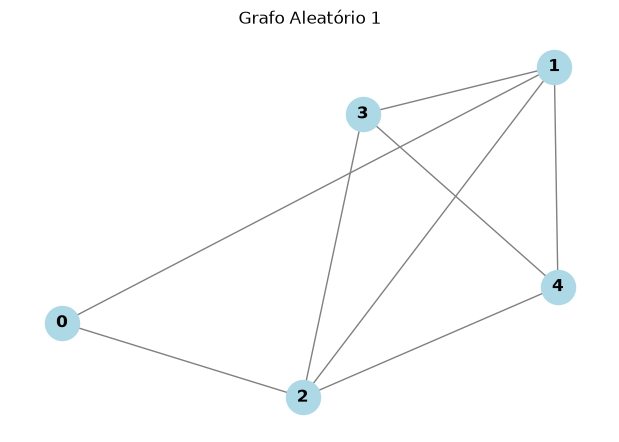

A) Planaridade:
   - O grafo É PLANAR (Passou nos testes de Euler e Kuratowski).

B) Pontos de Articulação:
   - O grafo NÃO possui pontos de articulação.

C) Ciclos e Caminhos Eulerianos:
   - O grafo possui apenas um CAMINHO EULERIANO.
   - Percurso de Fleury: 4 -> 2 -> 0 -> 1 -> 4 -> 3 -> 1 -> 2 -> 3

GRAFO 2 (5 vértices)


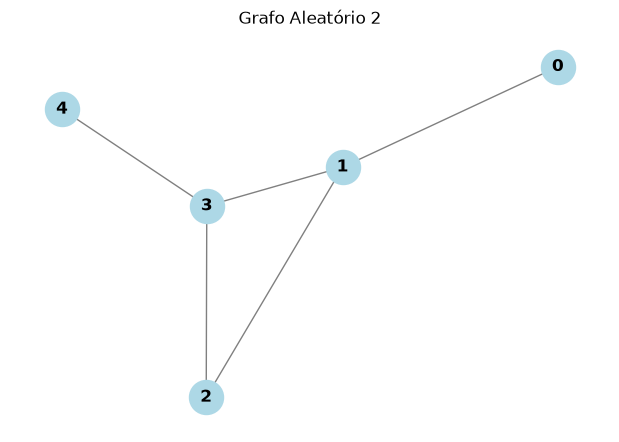

A) Planaridade:
   - O grafo É PLANAR (Passou nos testes de Euler e Kuratowski).

B) Pontos de Articulação:
   - O grafo possui pontos de articulação: [1, 3]

C) Ciclos e Caminhos Eulerianos:
   - O grafo NÃO possui Caminho nem Ciclo Euleriano (falhou na contagem de graus ímpares).

GRAFO 3 (5 vértices)


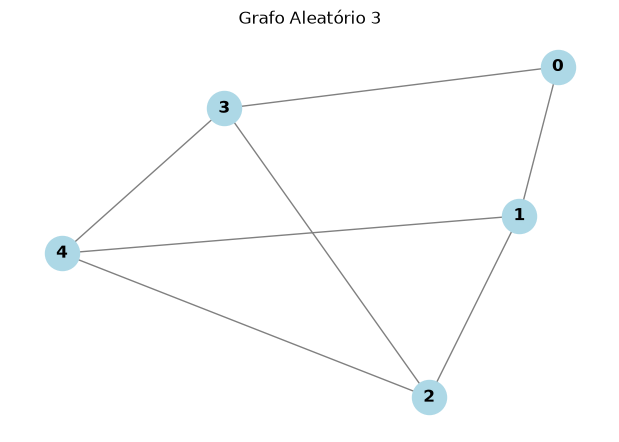

A) Planaridade:
   - O grafo É PLANAR (Passou nos testes de Euler e Kuratowski).

B) Pontos de Articulação:
   - O grafo NÃO possui pontos de articulação.

C) Ciclos e Caminhos Eulerianos:
   - O grafo NÃO possui Caminho nem Ciclo Euleriano (falhou na contagem de graus ímpares).


In [8]:
run(
    number_of_vertex = 5,
    is_dense = 1,
    seed = 42
)
plot()


### Usando grafos esparços

Executado com sucesso!

GRAFO 1 (10 vértices)


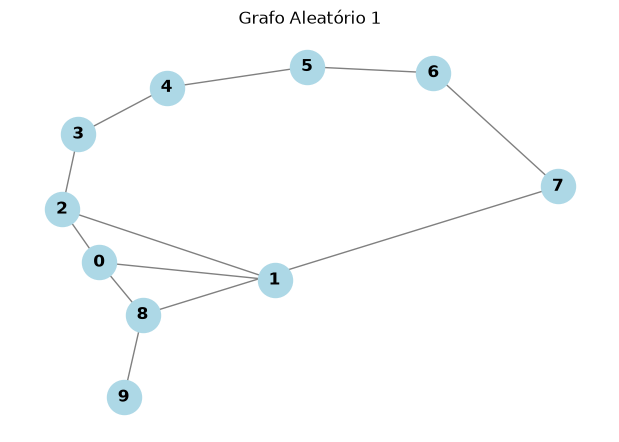

A) Planaridade:
   - O grafo É PLANAR (Passou nos testes de Euler e Kuratowski).

B) Pontos de Articulação:
   - O grafo possui pontos de articulação: [8]

C) Ciclos e Caminhos Eulerianos:
   - O grafo NÃO possui Caminho nem Ciclo Euleriano (falhou na contagem de graus ímpares).

GRAFO 2 (10 vértices)


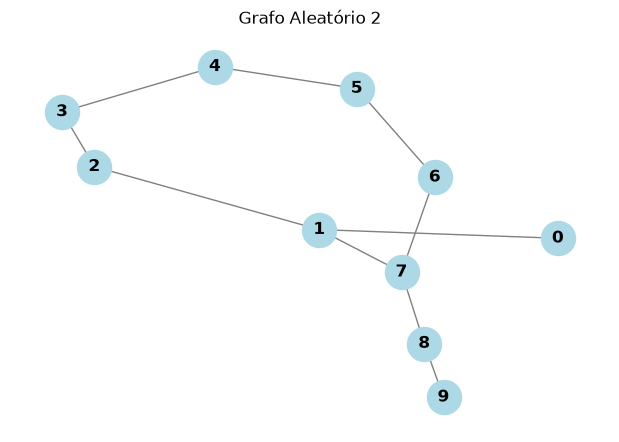

A) Planaridade:
   - O grafo É PLANAR (Passou nos testes de Euler e Kuratowski).

B) Pontos de Articulação:
   - O grafo possui pontos de articulação: [1, 7, 8]

C) Ciclos e Caminhos Eulerianos:
   - O grafo NÃO possui Caminho nem Ciclo Euleriano (falhou na contagem de graus ímpares).

GRAFO 3 (10 vértices)


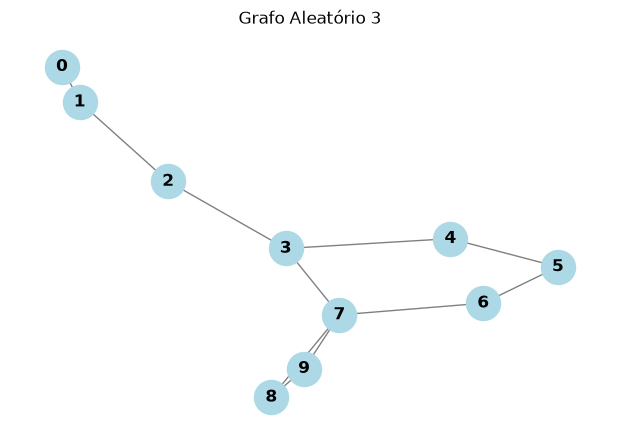

A) Planaridade:
   - O grafo É PLANAR (Passou nos testes de Euler e Kuratowski).

B) Pontos de Articulação:
   - O grafo possui pontos de articulação: [1, 2, 3, 7]

C) Ciclos e Caminhos Eulerianos:
   - O grafo possui apenas um CAMINHO EULERIANO.
   - Percurso de Fleury: 3 -> 7 -> 9 -> 8 -> 7 -> 6 -> 5 -> 4 -> 3 -> 2 -> 1 -> 0


In [9]:
run(
    number_of_vertex = 10,
    is_dense = 0,
    seed = 42
)
plot()


Executado com sucesso!

GRAFO 1 (7 vértices)


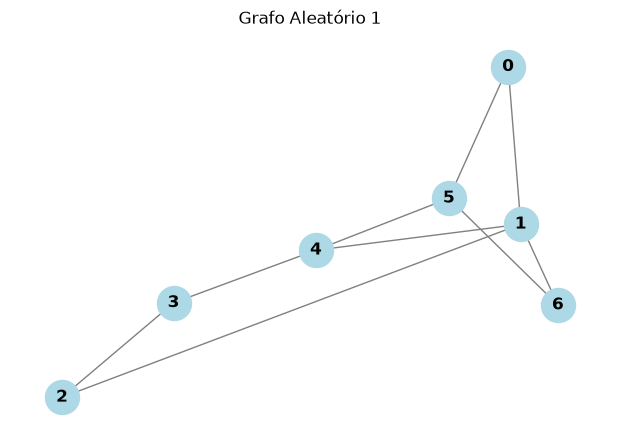

A) Planaridade:
   - O grafo É PLANAR (Passou nos testes de Euler e Kuratowski).

B) Pontos de Articulação:
   - O grafo NÃO possui pontos de articulação.

C) Ciclos e Caminhos Eulerianos:
   - O grafo possui apenas um CAMINHO EULERIANO.
   - Percurso de Fleury: 5 -> 0 -> 1 -> 6 -> 5 -> 4 -> 1 -> 2 -> 3 -> 4

GRAFO 2 (7 vértices)


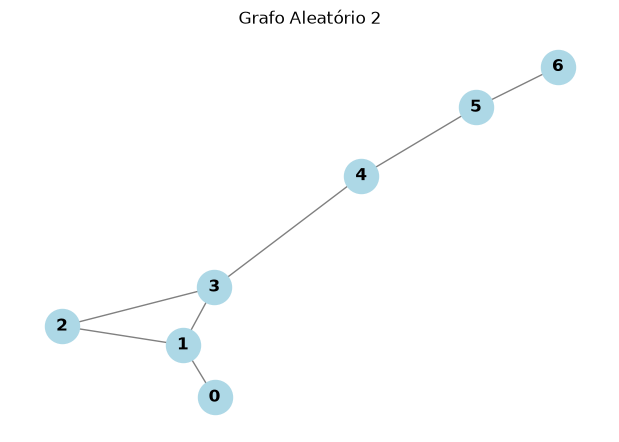

A) Planaridade:
   - O grafo É PLANAR (Passou nos testes de Euler e Kuratowski).

B) Pontos de Articulação:
   - O grafo possui pontos de articulação: [1, 3, 4, 5]

C) Ciclos e Caminhos Eulerianos:
   - O grafo NÃO possui Caminho nem Ciclo Euleriano (falhou na contagem de graus ímpares).

GRAFO 3 (7 vértices)


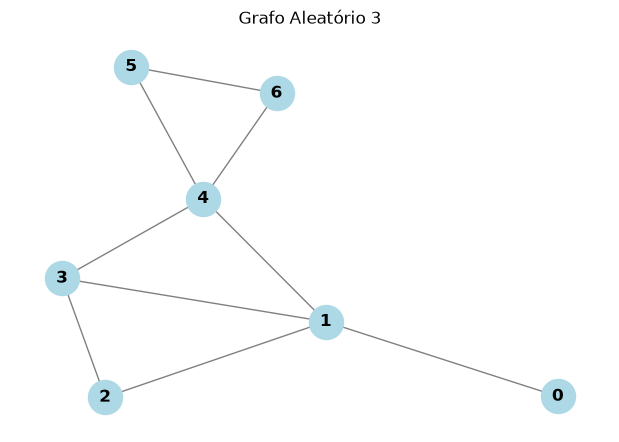

A) Planaridade:
   - O grafo É PLANAR (Passou nos testes de Euler e Kuratowski).

B) Pontos de Articulação:
   - O grafo possui pontos de articulação: [1, 4]

C) Ciclos e Caminhos Eulerianos:
   - O grafo possui apenas um CAMINHO EULERIANO.
   - Percurso de Fleury: 3 -> 1 -> 4 -> 6 -> 5 -> 4 -> 3 -> 2 -> 1 -> 0


In [10]:
run(
    number_of_vertex = 7,
    is_dense = 0,
    seed = 42
)
plot()


Executado com sucesso!

GRAFO 1 (5 vértices)


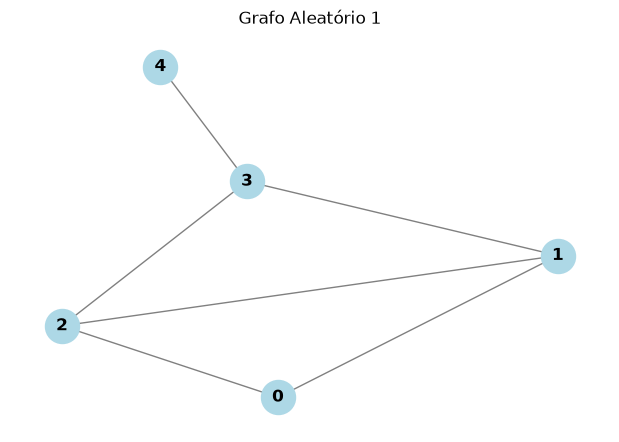

A) Planaridade:
   - O grafo É PLANAR (Passou nos testes de Euler e Kuratowski).

B) Pontos de Articulação:
   - O grafo possui pontos de articulação: [3]

C) Ciclos e Caminhos Eulerianos:
   - O grafo NÃO possui Caminho nem Ciclo Euleriano (falhou na contagem de graus ímpares).

GRAFO 2 (5 vértices)


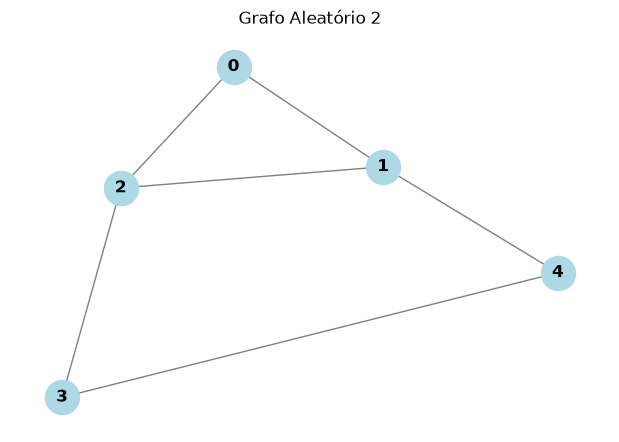

A) Planaridade:
   - O grafo É PLANAR (Passou nos testes de Euler e Kuratowski).

B) Pontos de Articulação:
   - O grafo NÃO possui pontos de articulação.

C) Ciclos e Caminhos Eulerianos:
   - O grafo possui apenas um CAMINHO EULERIANO.
   - Percurso de Fleury: 2 -> 0 -> 1 -> 4 -> 3 -> 2 -> 1

GRAFO 3 (5 vértices)


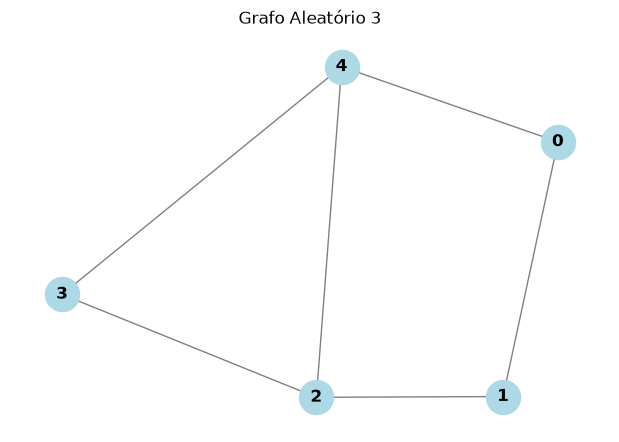

A) Planaridade:
   - O grafo É PLANAR (Passou nos testes de Euler e Kuratowski).

B) Pontos de Articulação:
   - O grafo NÃO possui pontos de articulação.

C) Ciclos e Caminhos Eulerianos:
   - O grafo possui apenas um CAMINHO EULERIANO.
   - Percurso de Fleury: 4 -> 2 -> 3 -> 4 -> 0 -> 1 -> 2


In [11]:
run(
    number_of_vertex = 5,
    is_dense = 0,
    seed = 42
)
plot()
